# ANALYSE DU STOCK ET DES VENTES DU SITE BOTTLENECK

# OBJECTIF DE CE NOTEBOOK

Bienvenue dans l'outil plébiscité par les analystes de données Jupyter.

Il s'agit d'un outil permettant de mixer et d'alterner code, texte et graphiques.

Cet outil est formidable pour plusieurs raisons:

+ Il permet de tester des lignes de codes au fur et à mesure de votre rédaction, de constater immédiatement le résultat d'une instruction, de la corriger si nécessaire.
+ Il permet aussi de rédiger du texte pour expliquer l'approche suivie ou les résultats d'une analyse et de le mettre en forme grâce à du code html ou plus simple avec **Markdown**
+ Il est possible d'ajouter des graphiques

Pour vous aider dans vos premiers pas à l'usage de Jupyter et de Python, nous avons rédigé ce notebook en vous indiquant les instructions à suivre.

Il vous suffit pour cela de saisir le code Python répondant à l'instruction donnée.

Vous verrez de temps à autre le code Python répondant à une instruction donnée mais cela est fait pour vous aider à comprendre la nature du travail qui vous est demandé.

Et gardez à l'esprit qu'il n'y a pas de solution unique pour résoudre un problème et qu'il y a autant de résolutions de problèmes que de développeurs ;)...



# Etape 1 - Importation des librairies et chargement des fichiers

## Importation des librairies

In [1]:
#Importation de la librairie Pandas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#Importation de la librairie plotly express
import plotly.express as px  # permet de créer des graphiques interactifs avec peu de code.


In [3]:
#permet d'aller prendre les fichiers directement dans mon drive
from google.colab import drive
drive.mount('/content/drive/')
%cd /content/drive/My Drive/Colab Notebooks/

Mounted at /content/drive/
/content/drive/My Drive/Colab Notebooks


In [4]:
#Trouver dans Google l'instruction permettant d'afficher toutes les colonnes d'un dataframe
#Saisir dans Google les mots clés "display all columns dataframe Pandas" par exemple.
#Dans les résultats de la recherche, privilégier les solutions provenant de Stack Overflow ou Medium
pd.set_option('display.max_columns', None) #dit à pandas d’afficher toutes les colonnes, none supprime la limite

## Chargements des fichiers

In [5]:
#Importation du fichier web.xlsx
df_web = pd.read_excel("web.xlsx")
#Importation du fichier erp.xlsx
df_erp = pd.read_excel("erp.xlsx")
#Importation du fichier liaison.xlsx
df_liaison = pd.read_excel("liaison.xlsx")

/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


# Etape 2 - Analyse exploratoire des fichiers

## 2.1 - Analyse exploratoire du fichier erp.xlsx

In [6]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(df_erp.shape[0]))
print("Le tableau comporte {} colonne(s)".format(df_erp.shape[1]))

Le tableau comporte 825 observation(s) ou article(s)
Le tableau comporte 6 colonne(s)


In [7]:
#Consulter le nombre de colonnes
print("Le nombre de colonnes est de : ",df_erp.shape[1],"\n")
#La nature des données dans chacune des colonnes
print("Nature des données pour chaques colonnes :\n", df_erp.dtypes,"\n")
#Le nombre de valeurs présentes dans chacune des colonnes
print("Nombre de valeurs par colonnes :\n", df_erp.count())


Le nombre de colonnes est de :  6 

Nature des données pour chaques colonnes :
 product_id          int64
onsale_web          int64
price             float64
stock_quantity      int64
stock_status       object
purchase_price    float64
dtype: object 

Nombre de valeurs par colonnes :
 product_id        825
onsale_web        825
price             825
stock_quantity    825
stock_status      825
purchase_price    825
dtype: int64


In [8]:
#Afficher les 5 premières lignes de la table
df_erp.head()


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
0,3847,1,24.2,16,instock,12.88
1,3849,1,34.3,10,instock,17.54
2,3850,1,20.8,0,outofstock,10.64
3,4032,1,14.1,26,instock,6.92
4,4039,1,46.0,3,outofstock,23.77


In [9]:
#Vérifier si il y a des lignes en doublon dans la colonne product_id
print("il y a : ", df_erp.duplicated(subset=["product_id"]).sum(), " doublons")
#.duplicated() va renvoyer pour chaque ligne de product_id True si dupliqué False sinon sachant que True = 1 et False = 0
# on fait ensuite la somme donc si 0 pas de doublons



il y a :  0  doublons


In [10]:
#Afficher les valeurs distinctes de la colonne stock_status
df_erp["stock_status"].unique()
#À quelle(s) autre(s) colonne(s) sont-elles liées ?
#Elle est liée à la colonne stock_quantity

array(['instock', 'outofstock'], dtype=object)

In [11]:
#Création d'une colonne "stock_status_2"
#La valeur de cette deuxième colonne sera fonction de la valeur dans la colonne "stock_quantity"
#Si la valeur de la colonne "stock_quantity" est nulle, renseigner "outofstock" sinon mettre "instock"
df_erp["stock_status_2"] = np.where(df_erp["stock_quantity"] <= 0, "outofstock", "instock") #permet de créer une colonne ou "outofstock" est retourné si condition est vrai sinon "instock"
df_erp

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
0,3847,1,24.2,16,instock,12.88,instock
1,3849,1,34.3,10,instock,17.54,instock
2,3850,1,20.8,0,outofstock,10.64,outofstock
3,4032,1,14.1,26,instock,6.92,instock
4,4039,1,46.0,3,outofstock,23.77,instock
...,...,...,...,...,...,...,...
820,7203,0,45.0,30,instock,23.48,instock
821,7204,0,45.0,9,instock,24.18,instock
822,7247,1,54.8,6,instock,27.18,instock
823,7329,0,26.5,14,instock,13.42,instock


In [12]:
#Vérifions que les 2 colonnes sont identiques:
#Les 2 colonnes sont strictement identiques si les valeurs de chaque ligne sont strictement identiques 2 à 2
#La comparaison de 2 colonnes peut se réaliser simplement avec l'instruction ci-dessous:
df_erp["stock_status"] == df_erp["stock_status_2"]

#Le résultat est l'affichage de True ou False pour chacune des lignes du dataset
#C'est un bon début, mais difficile à exploiter

,0
0,True
1,True
2,True
3,True
4,False
...,...
820,True
821,True
822,True
823,True


In [13]:
#Mais il est possible de synthétiser ce résultat en effectuant la somme de cette colonne:
#True vaut 1 et False 0
#Nous devrions obtenir la somme de 825 qui correspond au nombre de lignes dans ce dataset
somme_stock_status = df_erp["stock_status"] == df_erp["stock_status_2"]
print("Nombre de lignes identiques : ", somme_stock_status.sum(), "sur 825")

#afficher la donnée erronée
print("\n", "Voici les données erronées :")
df_erp[somme_stock_status == False]

Nombre de lignes identiques :  823 sur 825

 Voici les données erronées :


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
4,4039,1,46.0,3,outofstock,23.77,instock
398,4885,1,18.7,0,instock,9.66,outofstock


In [14]:
#Si les colonnes ne sont absolument pas identiques ligne à ligne alors identifier la ligne en écart
##Dans ce cas je vous donne ce lien pour apprendre à réaliser des filtres dans Pandas:
##https://bitbucket.org/hrojas/learn-pandas/src/master/
##Lesson 3

In [15]:
#Corriger la ou les données incohérentes
# 1) on corrige en mettant les valeurs de stock_status 2 dans stock_status
df_erp["stock_status"] = df_erp["stock_status_2"]

# 2) on vérifie qu'il n'y ai plus de différences
somme_stock_status = df_erp["stock_status"] == df_erp["stock_status_2"]
print("Nombre de lignes identiques : ", somme_stock_status.sum(), "sur 825")

# 3) On vérifie s'il y a des valeurs négatives
mask = df_erp["stock_quantity"] < 0
print("\n", "Lignes avec des valeurs négatives : ")
df_erp[mask]





Nombre de lignes identiques :  825 sur 825

 Lignes avec des valeurs négatives : 


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
449,4973,0,10.0,-10,outofstock,4.96,outofstock
573,5700,1,44.5,-1,outofstock,22.30,outofstock


## 2.1.1 - Analyse exploratoire de chaque variable du fichier erp.xlsx

### 2.1.1.1 - Analyse de la variable PRIX

In [16]:
###############
## LES PRIX  ##
###############

#Vérification des prix: Y a t-il des prix non renseignés, négatifs ou nuls?
#Afficher le ou les prix non renseignés dans la colonne "price"
print("Nombres d'articles avec un prix non renseigné: {}".format(df_erp['price'].isnull().sum())) # isnull renvoie booléen vrai faux puis somme donc si 0 pas de valeur non renseignées
#Afficher le prix minimum de la colonne "price"
print("Prix minimal : {}".format(df_erp['price'].min()),"€")
#Afficher le prix maximum de la colonne "price"
print("Prix maximal : {}".format(df_erp['price'].max()),"€")
#Afficher les prix inférieurs à 0 (qu'est-ce qu'il faut en faire ?) il s'agit probablement d'une erreur donc on peut les supprimer
mask = df_erp['price'] < 0
display(df_erp[mask])
# On corrige en supprimant les valeurs négatives
df_erp = df_erp[~mask]  # ~veut dire que l'on prends toutes les valeurs non présentent dans le mask
df_erp



Nombres d'articles avec un prix non renseigné: 0
Prix minimal : -20.0 €
Prix maximal : 225.0 €


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
151,4233,0,-20.0,0,outofstock,10.33,outofstock
469,5017,0,-8.0,0,outofstock,4.34,outofstock
739,6594,0,-9.1,19,instock,4.61,instock


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
0,3847,1,24.2,16,instock,12.88,instock
1,3849,1,34.3,10,instock,17.54,instock
2,3850,1,20.8,0,outofstock,10.64,outofstock
3,4032,1,14.1,26,instock,6.92,instock
4,4039,1,46.0,3,instock,23.77,instock
...,...,...,...,...,...,...,...
820,7203,0,45.0,30,instock,23.48,instock
821,7204,0,45.0,9,instock,24.18,instock
822,7247,1,54.8,6,instock,27.18,instock
823,7329,0,26.5,14,instock,13.42,instock


### 2.1.1.2 - Analyse de la variable STOCK

In [17]:
#######################
### stock_quantity  ###
#######################

#Vérification de la colonne stock quantity
#Afficher la quantité minimum de la colonne "stock_quantity"
print("Stock minimal : {}".format(df_erp['stock_quantity'].min()))

#Afficher la quantité maximum de la colonne "stock_quantity"
print("Stock maximal : {}".format(df_erp['stock_quantity'].max()))

#Afficher les stocks inférieurs à 0 (qu'est-ce qu'il faut en faire ?) un stock ne peut etre négatif donc on le met égale à 0 car comme vu plus haut ces stocks étaient notés outofstock
mask = df_erp["stock_quantity"] < 0
display(df_erp[mask])

#Remplacer les valeurs de stock négatives par 0
df_erp.loc[mask, 'stock_quantity'] = 0

Stock minimal : -10
Stock maximal : 145


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
449,4973,0,10.0,-10,outofstock,4.96,outofstock
573,5700,1,44.5,-1,outofstock,22.30,outofstock


### 2.1.1.3 - Analyse de la variable ONSALE_WEB

In [18]:
#Vérification de la colonne onsale_web et des valeurs qu'elle contient. Que signifient-elles? si 1 en vente sur le site sinon si 0 pas en vente sur le site
df_erp["onsale_web"].unique()

#Calculer le nombre d'articles en vente sur le site
print("Nombre d'articles en vente sur le site : {}".format(df_erp["onsale_web"].sum()))


Nombre d'articles en vente sur le site : 716


In [19]:
#Quelles sont les colonnes à conserver selon vous? Toutes les colonnes sauf celle que l'on a crée et onsale_web


In [20]:
#Supprimer la colonne comportant le libellé "stock_status_2" car elle est redondante
#avec la colonne "stock_status".
df_erp = df_erp.drop(columns=["stock_status_2","onsale_web"])
df_erp


,product_id,price,stock_quantity,stock_status,purchase_price
0,3847,24.2,16,instock,12.88
1,3849,34.3,10,instock,17.54
2,3850,20.8,0,outofstock,10.64
3,4032,14.1,26,instock,6.92
4,4039,46.0,3,instock,23.77
...,...,...,...,...,...
820,7203,45.0,30,instock,23.48
821,7204,45.0,9,instock,24.18
822,7247,54.8,6,instock,27.18
823,7329,26.5,14,instock,13.42


### 2.1.1.4 - Analyse de la variable prix d'achat

In [21]:
######################
##   prix d'achat   ##
######################

#Vérification de la colonne purchase_price :
#Afficher le ou les prix non renseignés dans la colonne "purchase_price"
print("Nombres d'articles avec un prix d'achat non renseigné: {}".format(df_erp['purchase_price'].isnull().sum()))

#Afficher le prix minimum de la colonne "purchase_price"
print("Prix d'achat minimal : {}".format(df_erp['purchase_price'].min()),"€")

#Afficher le prix maximum de la colonne "purchase_price"
print("Prix d'achat maximal : {}".format(df_erp['purchase_price'].max()),"€")

Nombres d'articles avec un prix d'achat non renseigné: 0
Prix d'achat minimal : 2.74 €
Prix d'achat maximal : 137.81 €


## 2.2 - Analyse exploratoire du fichier web.xlsx


In [22]:
#Dimension du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(df_web.shape[0]))
print("Le tableau comporte {} colonne(s)".format(df_web.shape[1]))

#Nombre d'observations
print("Nb observations : ",df_web.shape[0])

#Nombre de caractéristiques
print("Nb caractéristiques : ",df_web.shape[1])

Le tableau comporte 1513 observation(s) ou article(s)
Le tableau comporte 29 colonne(s)
Nb observations :  1513
Nb caractéristiques :  29


In [23]:
#Consulter le nombre de colonnes
print(df_web.shape[1])
#La nature des données dans chacune des colonnes
print(df_web.dtypes)
#Le nombre de valeurs présentes dans chacune des colonnes
print(df_web.count())


29
sku                              object
virtual                           int64
downloadable                      int64
rating_count                      int64
average_rating                  float64
total_sales                     float64
tax_status                       object
tax_class                       float64
post_author                     float64
post_date                datetime64[ns]
post_date_gmt            datetime64[ns]
post_content                    float64
product_type                     object
post_title                       object
post_excerpt                     object
post_status                      object
comment_status                   object
ping_status                      object
post_password                   float64
post_name                        object
post_modified            datetime64[ns]
post_modified_gmt        datetime64[ns]
post_content_filtered           float64
post_parent                     float64
guid                             obje

In [24]:
#Selon vous, quelles sont les colonnes à conserver ? Toutes les colonnes ou il y a des infos non-vides et en lien avec les produits mais on supprime ce qui est en lien avec les posts (RGPD)


In [25]:
#Si vous avez défini des colonnes à supprimer, effectuer l'opération
df_web = df_web.drop(columns=["tax_class", "virtual", "ping_status", "tax_status", "post_name", "post_modified", "post_modified_gmt", "post_parent", "guid", "menu_order", "post_mime_type", "comment_count", "downloadable", "rating_count", "average_rating", "post_author", "post_date", "post_date_gmt", "post_excerpt", "post_status", "comment_status","post_content","post_password","post_content_filtered"])



In [26]:
#Visualisation des valeurs de la colonne sku
df_web["sku"].unique()

#Quelles sont les valeurs qui ne semblent pas respecter la régle de codification? Les valeurs vides et non numériques



array([11862, 16057, 14692, 16295, 15328, 15471, 16515, 16246, nan, 13572,
       16513, 16585, 16269, 15526, 12869, 15575, 11586, 14338, 15425,
       16560, 15361, 13809, 11587, 15022, 14323, 16342, 16029, 15475,
       13754, 14680, 15875, 9636, 13849, 13662, 16564, 13557, 15429,
       14712, 15032, 15481, 15448, 16580, 15441, 804, 15300, 13958, 16071,
       15678, 13895, 15711, 12882, 16053, 13766, 16247, 12640, 15292,
       15476, 15670, 16189, 16038, 14864, 16044, 15324, 15531, 15953,
       15413, 15733, 14366, 15895, 15892, 16472, 15185, 16010, 15793,
       15849, 12315, 15741, 15934, 15148, 15781, 15659, 15106, 15490,
       14507, 14149, 16307, 13736, 14090, 16037, 15758, 14661, 12587,
       15337, 15489, 15201, 16305, 16131, 13435, 15747, 12203, 14509,
       14768, 16262, 14561, 16505, 15717, 16129, 13460, 15871, 15940,
       11602, 13127, 13520, 15480, 13032, 15436, 15269, 15910, 19821,
       16263, 15138, 15146, 15126, 15482, 16186, 13905, 16540, 15856,
       1567

In [27]:
#Si vous avez identifié des codes articles ne respectant pas la régle de codification, consultez-les

# 1) Les lignes non numériques
mask_non_numeric = pd.to_numeric(df_web['sku'], errors='coerce').isna() & df_web['sku'].notna() #affiche les valeurs non-vides d'origine et qui sont vides après to_numeric car elles n'étaient pas numériques
display(df_web.loc[mask_non_numeric].head())

# 2)Couper la partie après le '-'
# extract before first dash, strip espaces et normalise les blancs invisibles
clean = (df_web['sku'].astype(str).str.partition('-')[0])   # récupère tout avant le premier '-'

# convertir en numérique puis en Int64 nullable (garde <NA> pour non-convertibles)
df_web['sku'] = pd.to_numeric(clean, errors='coerce').astype('Int64') #les valeurs textuelles von aussi devenir Nan

# vérif
print("\n", "Le type de la colonne sku est :", df_web['sku'].dtype, "\n")

# ça marque les valeurs qui existent mais ne sont pas numériques
display(df_web.loc[mask_non_numeric].head()) #on voit que la valeur avec le tiret est corrigé et le bon a été remplacé par nan donc c'est tout bon




,sku,total_sales,product_type,post_title,post_type
272,13127-1,4.0,Vin,Clos du Mont-Olivet Châteauneuf-du-Pape 2007,product
842,bon-cadeau-25-euros,7.0,Autre,Bon cadeau de 25€,attachment
1117,13127-1,4.0,Vin,Clos du Mont-Olivet Châteauneuf-du-Pape 2007,attachment
1387,bon-cadeau-25-euros,7.0,NaN,Bon cadeau de 25€,product



 Le type de la colonne sku est : Int64 



,sku,total_sales,product_type,post_title,post_type
272,13127,4.0,Vin,Clos du Mont-Olivet Châteauneuf-du-Pape 2007,product
842,<NA>,7.0,Autre,Bon cadeau de 25€,attachment
1117,13127,4.0,Vin,Clos du Mont-Olivet Châteauneuf-du-Pape 2007,attachment
1387,<NA>,7.0,NaN,Bon cadeau de 25€,product


In [28]:
#Identifier les lignes sans code article
# on va devoir supprimer ses lignes car inexploitables si l'on a pas le sku (qui permet de faire la liaison entre les tables)

# Repérér combien et ou elles sont #il y en avait à l'origine 85 mais on en a 2 de plus du fait des bon cadeau que l'on a transformé en Nan
mask_to_drop = df_web["sku"].isna()
print("Nombre de lignes à supprimer :", mask_to_drop.sum())
display(df_web.loc[mask_to_drop].head(10))  # aperçu

Nombre de lignes à supprimer : 87


,sku,total_sales,product_type,post_title,post_type
8,<NA>,NaN,NaN,NaN,NaN
20,<NA>,NaN,NaN,NaN,NaN
30,<NA>,NaN,NaN,NaN,NaN
37,<NA>,NaN,NaN,NaN,NaN
41,<NA>,NaN,NaN,NaN,NaN
47,<NA>,NaN,NaN,NaN,NaN
55,<NA>,NaN,NaN,NaN,NaN
75,<NA>,NaN,NaN,NaN,NaN
94,<NA>,NaN,NaN,NaN,NaN
127,<NA>,NaN,NaN,NaN,NaN


In [29]:
#Les lignes sans code article semblent être toutes non renseignées
#Pour s'en assurer, réaliser les étapes suivantes:
#1 - Créer un dataframe avec uniquement les lignes sans code article
mask_to_drop = df_web["sku"].isna()
df_web_vide = df_web.loc[mask_to_drop].reset_index(drop=True)

#2 - Utiliser la fonction df.info() sur ce nouveau dataframe pour observer le nombre de valeurs renseignées dans chacune des colonnes
df_web_vide.info()

#3 - Que constatez-vous? Sur les 87 non nulles  seulement 4 contiennent des infos (dont deux étaient des bons) et le total des ventes est négatif pour les 2 autres ce qui ne fait pas sens on peut donc les retirer
df_web_vide[df_web_vide['total_sales'].notna()]



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87 entries, 0 to 86
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sku           0 non-null      Int64  
 1   total_sales   4 non-null      float64
 2   product_type  3 non-null      object 
 3   post_title    4 non-null      object 
 4   post_type     4 non-null      object 
dtypes: Int64(1), float64(1), object(3)
memory usage: 3.6+ KB


,sku,total_sales,product_type,post_title,post_type
56,<NA>,7.0,Autre,Bon cadeau de 25€,attachment
66,<NA>,-56.0,Vin,Pierre Jean Villa Condrieu Jardin Suspendu 2018,product
68,<NA>,-17.0,Vin,Pierre Jean Villa Côte Rôtie Fongeant 2017,product
82,<NA>,7.0,NaN,Bon cadeau de 25€,product


In [30]:
#Pour les codes articles identifiés, réaliser une analyse et définir l'action à entreprendre (on va supprimer les lignes vides)
#et pour l'autre on a enlevé le -1 qui est une erreur et on fera la moyenne de total_sales afin d'en avoir une seule car sku doit être unique

# 1) Supprimer les lignes vides
mask_to_drop = df_web["sku"].isna()
display(df_web.loc[mask_to_drop].head())
df_web = df_web.loc[~mask_to_drop].reset_index(drop=True) # ~ permet de prendre toutes les lignes qui ne sont pas dans le mask

# 2) Vérifier
display(df_web)





,sku,total_sales,product_type,post_title,post_type
8,<NA>,NaN,NaN,NaN,NaN
20,<NA>,NaN,NaN,NaN,NaN
30,<NA>,NaN,NaN,NaN,NaN
37,<NA>,NaN,NaN,NaN,NaN
41,<NA>,NaN,NaN,NaN,NaN


,sku,total_sales,product_type,post_title,post_type
0,11862,3.0,Vin,Gilles Robin Hermitage Rouge 2012,attachment
1,16057,5.0,Vin,Domaine Pellé Sancerre Rouge La Croix Au Garde...,attachment
2,14692,5.0,Vin,Château Fonréaud Bordeaux Blanc Le Cygne 2016,product
3,16295,14.0,Vin,Moulin de Gassac IGP Pays d'Hérault Guilhem Ro...,attachment
4,15328,2.0,Vin,Agnès Levet Côte Rôtie Maestria 2017,product
...,...,...,...,...,...
1421,16326,5.0,Vin,Camin Larredya Jurançon Moelleux Au Capcéu 2018,product
1422,15662,15.0,Vin,Chermette Domaine du Vissoux Beaujolais Griott...,product
1423,15329,3.0,Vin,Agnès Levet Côte Rôtie Péroline 2017,attachment
1424,14827,7.0,Vin,Marc Colin Et Fils Chassagne-Montrachet Blanc ...,attachment


In [31]:
#La clé pour chaque ligne est-elle unique? autrement dit, y a-t-il des doublons?
duplicats = df_web["sku"].value_counts()
duplicats = duplicats[duplicats > 1]
print(duplicats.head(20)) #seul le doublons 13127 est en 4 fois les autres toujours en 2 fois et a chaque fois pour l'un est une image l'autre est une ligne produit dans post_type

#1) On supprime toutes les lignes où sku est dupliqué ET post_type est différent de product
mask = (df_web["sku"].isin(duplicats.index))  & (df_web["post_type"] != "product") # duplicats.index = liste des sku qui sont en doublon, on prends donc les doublons qui n'ont pas product dans post_type
df_web = df_web.loc[~mask].reset_index(drop=True)

#2) On regarde a quoi ressemble nos 2 lignes avec les doublons restantes
print(df_web.loc[df_web['sku'].astype(str).str.contains('13127')])

#3) On fait la moyenne pour le dernier doublons afin de s'en débarasser
df_web = (df_web.groupby('sku', as_index=False)
              .agg({
                  'total_sales': 'mean',
                  'product_type': 'first',
                  'post_title': 'first',
                  'post_type' : 'first'
              })) # On fait ici une aggrégation sur sku en réalisant la moyenne de total_sales et en affichant la première valeur dispo pour les autres colonnes.
df_web['total_sales'] = df_web['total_sales'].round(1)

df_web = df_web.rename(columns={'sku': 'id_web'})
df_web = df_web.rename(columns={'post_title': 'nom_cuvee'})

print(df_web.dtypes) #on vérifie et on voit que désormais toutes les valeurs sont bien numériques
df_web


sku
13127    4
15404    2
8365     2
3507     2
14773    2
15967    2
15812    2
16319    2
16004    2
15310    2
16097    2
15629    2
1364     2
15116    2
14101    2
14912    2
15036    2
16047    2
14184    2
14983    2
Name: count, dtype: Int64
       sku  total_sales product_type  \
54   13127          5.0          Vin   
126  13127          4.0          Vin   

                                       post_title post_type  
54   Clos du Mont-Olivet Châteauneuf-du-Pape 2012   product  
126  Clos du Mont-Olivet Châteauneuf-du-Pape 2007   product  
id_web            Int64
total_sales     float64
product_type     object
nom_cuvee        object
post_type        object
dtype: object


,id_web,total_sales,product_type,nom_cuvee,post_type
0,38,10.0,Vin,Emile Boeckel Crémant Brut Blanc de Blancs,product
1,41,6.0,Vin,Marcel Windholtz Eau de Vie de Marc de Gewurzt...,product
2,304,8.0,Champagne,Champagne Gosset Grande Réserve,product
3,523,0.0,Cognac,Cognac Normandin Mercier VFC,product
4,531,8.0,Champagne,Champagne Petit Lebrun &amp; Fils Blanc de Bla...,product
...,...,...,...,...,...
707,19815,3.0,Vin,Pierre Jean Villa Côte Rôtie Carmina 2017,product
708,19816,3.0,Vin,Clos du Mont-Olivet Châteauneuf-du-Pape Cuvée ...,product
709,19820,6.0,Vin,Tempier Bandol Migoua 2017,product
710,19821,8.0,Vin,Tempier Bandol Tourtine 2017,product


In [32]:
#J'ai remarqué qu'il y avait de l'huile d'olive, je vais donc supprimer ces lignes car elle ne doivent pas faire partie d'une analyse sur le vin
mask = df_web['product_type'] == "Huile d'olive"

#combien de ligne correspondent au mask ?
print("Nombre de lignes à supprimer :", mask.sum())
display(df_web.loc[mask].head())  # aperçu
df_web = df_web.loc[~mask].reset_index(drop=True)
print(df_web['product_type'].unique())

#créer une liste avec toutes les id_web
liste_id_web = df_web['id_web'].tolist()
df_web


Nombre de lignes à supprimer : 3


,id_web,total_sales,product_type,nom_cuvee,post_type
30,7033,5.0,Huile d'olive,Huile d'Olive Extra Vierge Planeta Selezione C...,product
47,11258,7.0,Huile d'olive,Huile d'Olive Extra Vierge Planeta 50cl,product
139,13849,10.0,Huile d'olive,Huiles d'Olive Extra Vierge Planeta 3x 10cl,product


['Vin' 'Champagne' 'Cognac' 'Whisky' 'Gin']


,id_web,total_sales,product_type,nom_cuvee,post_type
0,38,10.0,Vin,Emile Boeckel Crémant Brut Blanc de Blancs,product
1,41,6.0,Vin,Marcel Windholtz Eau de Vie de Marc de Gewurzt...,product
2,304,8.0,Champagne,Champagne Gosset Grande Réserve,product
3,523,0.0,Cognac,Cognac Normandin Mercier VFC,product
4,531,8.0,Champagne,Champagne Petit Lebrun &amp; Fils Blanc de Bla...,product
...,...,...,...,...,...
704,19815,3.0,Vin,Pierre Jean Villa Côte Rôtie Carmina 2017,product
705,19816,3.0,Vin,Clos du Mont-Olivet Châteauneuf-du-Pape Cuvée ...,product
706,19820,6.0,Vin,Tempier Bandol Migoua 2017,product
707,19821,8.0,Vin,Tempier Bandol Tourtine 2017,product


## 2.3 - Analyse exploratoire du fichier liaison.xlsx

In [33]:
#Dimension du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(df_liaison.shape[0]))
print("Le tableau comporte {} colonne(s)".format(df_liaison.shape[1]))

#Nombre d'observations
print("Nb observations : ",df_liaison.shape[0])

#Nombre de caractéristiques
print("Nb caractéristiques : ",df_liaison.shape[1])


Le tableau comporte 825 observation(s) ou article(s)
Le tableau comporte 2 colonne(s)
Nb observations :  825
Nb caractéristiques :  2


In [34]:
#Consulter le nombre de colonnes
df_liaison.shape[1]
#La nature des données dans chacune des colonnes
df_liaison.dtypes
#Le nombre de valeurs présentes dans chacune des colonnes
df_liaison.count()


,0
id_web,734
product_id,825


In [35]:
#Les valeurs de la colonne "product_id" sont-elles toutes uniques?
df_liaison["product_id"].is_unique


True

In [36]:
#Les valeurs de la colonne "id_web" sont-elles toutes uniques?
df_liaison["id_web"].is_unique

False

In [37]:
#Avons-nous des articles sans correspondance? Oui

#combien de lignes vides pour id_web
print("Nombre de lignes vides pour id_web :", df_liaison["id_web"].isna().sum())
# 1) Supprimer les lignes vides
mask_to_drop = df_liaison["id_web"].isna()
df_liaison = df_liaison.loc[~mask_to_drop].reset_index(drop=True)
display(df_liaison)


# 2) Couper la partie après le '-'
clean = (df_liaison['id_web'].astype(str).str.partition('-')[0])   # récupère tout avant le premier '-'


# 3) Convertir en numérique puis en Integer
df_liaison['id_web'] = pd.to_numeric(clean, errors='coerce').astype('Int64') #il y a aussi une ligne avec bon cadeau qui sera supprimé mais cela ne correspond pas à un produit que l'on vends donc on peut le supprimer.

# 4) Afficher les doublons
df_liaison[df_liaison.duplicated(subset=['id_web'], keep=False)] # certains produits de l'ERP correspondent au même produit sur ID_web, a nettoyer après la jointure des tables
#keep = false affiche toutes les occurences des doublons



Nombre de lignes vides pour id_web : 91


,id_web,product_id
0,15298,3847
1,15296,3849
2,15300,3850
3,19814,4032
4,19815,4039
...,...,...
729,15891,7023
730,15887,7025
731,13127-1,7247
732,14680-1,7329


,id_web,product_id
17,13127,4053
341,14680,4757
731,13127,7247
732,14680,7329


# Etape 3 - Jonction des fichiers

## Etape 3.1 - Jonction du fichier df_erp et df_liaison

In [38]:
#Fusion des fichiers df_erp et df_liaison
df_merge = pd.merge(df_erp, df_liaison, on='product_id', how='left', indicator=True)

# statistiques rapides
print(df_merge['_merge'].value_counts())

# lignes de df_erp qui n'ont pas matché (left_only)
unmatched_left = df_merge[df_merge['_merge'] == 'left_only']
print("Lignes df_erp sans correspondant dans df_liaison :", len(unmatched_left))
display(unmatched_left.head())



_merge
both          734
left_only      88
right_only      0
Name: count, dtype: int64
Lignes df_erp sans correspondant dans df_liaison : 88


,product_id,price,stock_quantity,stock_status,purchase_price,id_web,_merge
19,4055,86.1,0,outofstock,37.88,<NA>,left_only
49,4090,73.0,0,outofstock,33.79,<NA>,left_only
50,4092,47.0,0,outofstock,25.25,<NA>,left_only
119,4195,14.1,0,outofstock,7.36,<NA>,left_only
131,4209,73.5,0,outofstock,33.01,<NA>,left_only


In [39]:
#Y a t-il des lignes ne "matchant" pas entre les 2 fichiers? oui il y en a 88


## Etape 3.2 - Jonction du fichier df_merge et df_web

In [40]:
#Fusionner les datasets df_merge et df_web
df_merge_global = pd.merge(df_merge, df_web, on='id_web', how='left')
display(df_merge_global)
print(df_merge_global["id_web"].isna().sum())

# Afficher les lignes doublons pour id_web
display(df_merge_global[df_merge_global.duplicated(subset=['id_web'], keep=False)])

# Pour chacune des lignes doublons agréger par id_web et faire la moyenne pour price, stock_quantity et purchase_price pour le reste garder la première valeur supprime aussi les ligne vides, permet de nettoyer les doublons de id_web
df_merge_global = df_merge_global.groupby('id_web', as_index=False).agg({
              'product_id': 'first',
              'price': 'mean',
              'stock_quantity': 'mean',
              'stock_status': 'first',
              'purchase_price': 'mean',
              '_merge': 'first',
              'total_sales': 'first',
              'product_type': 'first',
              'nom_cuvee': 'first',
              'post_type' : 'first',})

print("lignes vides restantes : ", df_merge_global["id_web"].isna().sum())

#Les valeurs de la colonne "id_web" sont-elles toutes uniques?
print(df_merge_global["id_web"].is_unique) #oui on est tout bon



,product_id,price,stock_quantity,stock_status,purchase_price,id_web,_merge,total_sales,product_type,nom_cuvee,post_type
0,3847,24.2,16,instock,12.88,15298,both,6.0,Vin,Pierre Jean Villa Saint-Joseph Préface 2018,product
1,3849,34.3,10,instock,17.54,15296,both,9.0,Vin,Pierre Jean Villa Saint-Joseph Rouge Tildé 2017,product
2,3850,20.8,0,outofstock,10.64,15300,both,0.0,Vin,Pierre Jean Villa Crozes-Hermitage Accroche Co...,product
3,4032,14.1,26,instock,6.92,19814,both,12.0,Vin,Pierre Jean Villa IGP Collines Rhodaniennes Ga...,product
4,4039,46.0,3,instock,23.77,19815,both,3.0,Vin,Pierre Jean Villa Côte Rôtie Carmina 2017,product
...,...,...,...,...,...,...,...,...,...,...,...
817,7203,45.0,30,instock,23.48,<NA>,left_only,NaN,NaN,NaN,NaN
818,7204,45.0,9,instock,24.18,<NA>,left_only,NaN,NaN,NaN,NaN
819,7247,54.8,6,instock,27.18,13127,both,4.5,Vin,Clos du Mont-Olivet Châteauneuf-du-Pape 2012,product
820,7329,26.5,14,instock,13.42,14680,both,7.0,Vin,Domaine Saint-Nicolas Fiefs Vendéens Blanc Le ...,product


89


,product_id,price,stock_quantity,stock_status,purchase_price,id_web,_merge,total_sales,product_type,nom_cuvee,post_type
17,4053,44.3,7,instock,22.20,13127,both,4.5,Vin,Clos du Mont-Olivet Châteauneuf-du-Pape 2012,product
19,4055,86.1,0,outofstock,37.88,<NA>,left_only,NaN,NaN,NaN,NaN
49,4090,73.0,0,outofstock,33.79,<NA>,left_only,NaN,NaN,NaN,NaN
50,4092,47.0,0,outofstock,25.25,<NA>,left_only,NaN,NaN,NaN,NaN
119,4195,14.1,0,outofstock,7.36,<NA>,left_only,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
816,7201,31.0,18,instock,16.02,<NA>,left_only,NaN,NaN,NaN,NaN
817,7203,45.0,30,instock,23.48,<NA>,left_only,NaN,NaN,NaN,NaN
818,7204,45.0,9,instock,24.18,<NA>,left_only,NaN,NaN,NaN,NaN
819,7247,54.8,6,instock,27.18,13127,both,4.5,Vin,Clos du Mont-Olivet Châteauneuf-du-Pape 2012,product


lignes vides restantes :  0
True


In [41]:
#Avons-nous des lignes sans correspondance? Non, nous les avons supprimé

# 1) Afficher les lignes pour laquelle id_web n'est pas dans liste_id_web du dataframe df_web
display(df_merge_global[~df_merge_global["id_web"].isin(liste_id_web)])  #13849, 7033 et 11258	sont de l'huile d'olive que l'on a supprimé, le reste n'a juste pas de correspondance dans web.

# 2) A combien de lignes cela corresponds
print(df_merge_global[~df_merge_global["id_web"].isin(liste_id_web)].shape[0], "lignes n'ont pas de correspondances dans la table web")

# 3) Supprimer ces lignes du dataset car elles n'ont pas de correspondance
df_merge_global = df_merge_global[df_merge_global["id_web"].isin(liste_id_web)].reset_index(drop=True)
df_merge_global






,id_web,product_id,price,stock_quantity,stock_status,purchase_price,_merge,total_sales,product_type,nom_cuvee,post_type
30,7033,5756,42.2,9.0,instock,25.85,both,NaN,None,None,None
47,11258,5760,13.1,24.0,instock,8.43,both,NaN,None,None,None
81,12601,4741,12.4,0.0,outofstock,6.66,both,NaN,None,None,None
127,13577,5957,39.0,0.0,outofstock,20.75,both,NaN,None,None,None
139,13771,4289,22.8,0.0,outofstock,11.90,both,NaN,None,None,None
142,13849,5761,19.5,125.0,instock,12.07,both,NaN,None,None,None
180,14360,4869,17.2,0.0,outofstock,9.33,both,NaN,None,None,None
185,14377,5955,27.3,0.0,outofstock,13.68,both,NaN,None,None,None
186,14379,5953,47.5,0.0,outofstock,23.81,both,NaN,None,None,None
212,14648,5505,10.1,0.0,outofstock,5.22,both,NaN,None,None,None


22 lignes n'ont pas de correspondances dans la table web


,id_web,product_id,price,stock_quantity,stock_status,purchase_price,_merge,total_sales,product_type,nom_cuvee,post_type
0,38,4729,8.6,26.0,instock,4.22,both,10.0,Vin,Emile Boeckel Crémant Brut Blanc de Blancs,product
1,41,4634,41.0,11.0,instock,20.12,both,6.0,Vin,Marcel Windholtz Eau de Vie de Marc de Gewurzt...,product
2,304,4141,39.0,123.0,instock,24.86,both,8.0,Champagne,Champagne Gosset Grande Réserve,product
3,523,5932,59.9,13.0,instock,27.18,both,0.0,Cognac,Cognac Normandin Mercier VFC,product
4,531,5047,22.5,76.0,instock,13.78,both,8.0,Champagne,Champagne Petit Lebrun &amp; Fils Blanc de Bla...,product
...,...,...,...,...,...,...,...,...,...,...,...
704,19815,4039,46.0,3.0,instock,23.77,both,3.0,Vin,Pierre Jean Villa Côte Rôtie Carmina 2017,product
705,19816,4054,71.6,6.0,instock,38.47,both,3.0,Vin,Clos du Mont-Olivet Châteauneuf-du-Pape Cuvée ...,product
706,19820,5561,58.0,8.0,instock,30.27,both,6.0,Vin,Tempier Bandol Migoua 2017,product
707,19821,5563,58.0,16.0,instock,29.07,both,8.0,Vin,Tempier Bandol Tourtine 2017,product


# Etape 4 - Analyse univariée des prix

## Etape 4.1 - Exploration par la visualisation de données

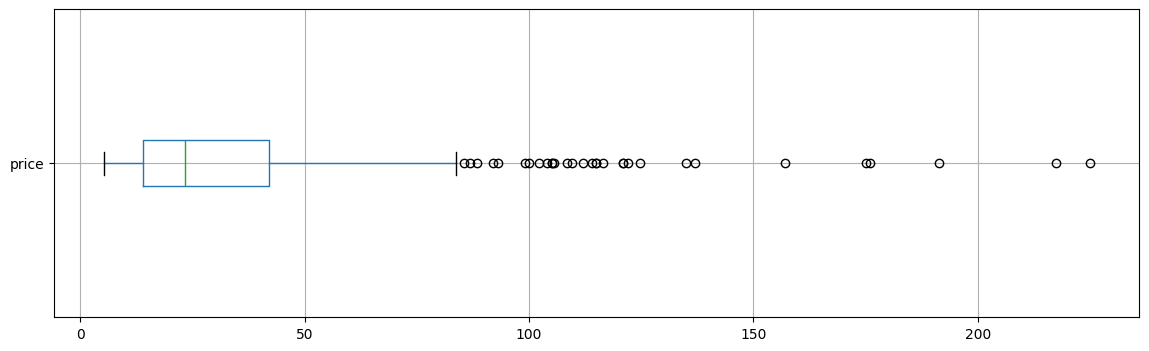

In [42]:
#Création d'une boîte à moustache de la répartition des prix grâce à Pandas
df_merge_global.boxplot(column='price', vert=False, figsize=(14, 4))
plt.show()

In [43]:
#Autre méthode avec plotly express
fig = px.box(df_merge_global, x='price', points=False, title='Distribution des prix', orientation='h')
fig.show()

## Etape 4.2 - Exploration par l'utilisation de méthodes statistiques

### Etape 4.2.1 - Identification par le Z-index

In [44]:
#Calculer la moyenne du prix
moyenne_prix = round(df_merge_global['price'].mean(),2)
print("Le prix moyen est de :", moyenne_prix,"€")

#Calculer l'écart-type du prix
ecart_type_prix = round(df_merge_global['price'].std(ddof=0),2) #ddof=0 pour représenter la population globale et non pas un échantillon
print("L'écart-type est de :", ecart_type_prix,"€")

#Calculer le Z-score
df_merge_global['prix_z'] = round((df_merge_global['price'] - moyenne_prix) / ecart_type_prix,1)

#Afficher les irrégularités
df_merge_global[df_merge_global['prix_z'] > 3]

# Le z-score mesure de combien d'écart-type une valeur s'éloigne de la moyenne


Le prix moyen est de : 32.35 €
L'écart-type est de : 27.65 €


,id_web,product_id,price,stock_quantity,stock_status,purchase_price,_merge,total_sales,product_type,nom_cuvee,post_type,prix_z
24,3510,4402,176.0,11.0,instock,78.25,both,3.0,Cognac,Cognac Frapin VIP XO,product,5.2
32,7819,4406,157.0,12.0,instock,69.08,both,4.0,Cognac,Cognac Frapin Château de Fontpinot 1989 20 Ans...,product,4.5
165,14220,4904,137.0,9.0,instock,67.95,both,3.0,Vin,Domaine Des Croix Corton Charlemagne Grand Cru...,product,3.8
195,14581,5001,217.5,18.0,instock,116.87,both,2.0,Vin,David Duband Charmes-Chambertin Grand Cru 2014,product,6.7
222,14775,5917,122.0,12.0,instock,54.24,both,3.0,Whisky,Wemyss Malts Single Cask Scotch Whisky Choc 'n...,product,3.2
242,14915,5612,124.8,19.0,instock,66.41,both,1.0,Vin,Domaine Weinbach Gewurztraminer Grand Cru Furs...,product,3.3
243,14923,6126,135.0,138.0,instock,80.33,both,5.0,Champagne,Champagne Gosset Célébris Vintage 2007,product,3.7
255,14983,5892,191.3,98.0,instock,116.06,both,6.0,Champagne,Coteaux Champenois Egly-Ouriet Ambonnay Rouge ...,product,5.7
266,15070,6216,121.0,14.0,instock,60.02,both,2.0,Vin,Domaine des Comtes Lafon Volnay 1er Cru Champa...,product,3.2
267,15072,6213,121.0,9.0,instock,63.14,both,3.0,Vin,Domaine des Comtes Lafon Volnay 1er Cru Santen...,product,3.2


In [45]:
#Quel est le seuil prix dont le z-score est supérieur à 3?
seuil = round(3*ecart_type_prix + moyenne_prix,2)
print("Le seuil de prix correspondant à un z-score de 3 est :", seuil, "€") #pour rappel la moustache supérieure était de 83.7€ comme moins sensible aux outliers

Le seuil de prix correspondant à un z-score de 3 est : 115.3 €


### Etape 4.2.2 - Identification par l'intervalle interquartile

In [46]:
#Utilisation de la fonction "describe" de Pandas pour l'étude des mesures de dispersion
round(df_merge_global['price'].describe(),2)

,price
count,709.00
mean,32.35
std,27.67
min,5.20
25%,14.05
50%,23.40
75%,42.00
max,225.00


In [47]:
#Définir un seuil pour les articles "outliers" en prix
#faire calcul ecart interquartile
ecart_interquartile = round(df_merge_global['price'].quantile(0.75) - df_merge_global['price'].quantile(0.25),2)
print("L'écart interquartile est de :", ecart_interquartile,"€")
# Calcul moustache supérieure
seuil = round(df_merge_global['price'].quantile(0.75) + 1.5*ecart_interquartile,2)
print("Le seuil est de :", seuil, "€")


L'écart interquartile est de : 27.95 €
Le seuil est de : 83.92 €


In [48]:
#Définir le nombre d'articles et la proportion de l'ensemble du catalogue "outliers"
outliers = df_merge_global[df_merge_global['price'] > seuil]
print(f"le nombre d'outliers probables est de : {len(outliers)}")
outliers_proportion = round(len(outliers) / len(df_merge_global),2)*100
print(f"la proportion d'outliers probables est de {outliers_proportion}%")



le nombre d'outliers probables est de : 31
la proportion d'outliers probables est de 4.0%


In [49]:
#Selon vous, ces outliers sont-ils justifiés ? Comment le démontrer si cela est possible ?
top10 = df_merge_global.sort_values('price', ascending=False).head(10)
top10
# une recherche rapide sur internet avec le nom de la bouteille et on voit que les prix sont en effet corrects


,id_web,product_id,price,stock_quantity,stock_status,purchase_price,_merge,total_sales,product_type,nom_cuvee,post_type,prix_z
545,15940,4352,225.0,0.0,outofstock,137.81,both,11.0,Champagne,Champagne Egly-Ouriet Grand Cru Millésimé 2008,product,7.0
195,14581,5001,217.5,18.0,instock,116.87,both,2.0,Vin,David Duband Charmes-Chambertin Grand Cru 2014,product,6.7
255,14983,5892,191.3,98.0,instock,116.06,both,6.0,Champagne,Coteaux Champenois Egly-Ouriet Ambonnay Rouge ...,product,5.7
24,3510,4402,176.0,11.0,instock,78.25,both,3.0,Cognac,Cognac Frapin VIP XO,product,5.2
297,15185,5767,175.0,12.0,instock,90.42,both,4.0,Vin,Camille Giroud Clos de Vougeot 2016,product,5.2
32,7819,4406,157.0,12.0,instock,69.08,both,4.0,Cognac,Cognac Frapin Château de Fontpinot 1989 20 Ans...,product,4.5
165,14220,4904,137.0,9.0,instock,67.95,both,3.0,Vin,Domaine Des Croix Corton Charlemagne Grand Cru...,product,3.8
243,14923,6126,135.0,138.0,instock,80.33,both,5.0,Champagne,Champagne Gosset Célébris Vintage 2007,product,3.7
242,14915,5612,124.8,19.0,instock,66.41,both,1.0,Vin,Domaine Weinbach Gewurztraminer Grand Cru Furs...,product,3.3
222,14775,5917,122.0,12.0,instock,54.24,both,3.0,Whisky,Wemyss Malts Single Cask Scotch Whisky Choc 'n...,product,3.2


# Etape 5 - Analyse univariée du CA, des quantités vendues, des stocks et de la marge ainsi qu'une analyse multivariée

## Etape 5.1 - Analyse des ventes en CA

In [50]:
##############################
# Calculer le CA du site web #
##############################

#Créer une colonne calculant le CA par article
df_merge_global["ca_par_article"] = round(df_merge_global["price"] * df_merge_global["total_sales"],2)
display(df_merge_global)

#Calculer la somme de la colonne "ca_par_article"
CA_site = df_merge_global["ca_par_article"].sum()
print(f"Le CA du site est de {CA_site}€")
#Ce résultat correspond au chiffre d'affaire du site web


,id_web,product_id,price,stock_quantity,stock_status,purchase_price,_merge,total_sales,product_type,nom_cuvee,post_type,prix_z,ca_par_article
0,38,4729,8.6,26.0,instock,4.22,both,10.0,Vin,Emile Boeckel Crémant Brut Blanc de Blancs,product,-0.9,86.0
1,41,4634,41.0,11.0,instock,20.12,both,6.0,Vin,Marcel Windholtz Eau de Vie de Marc de Gewurzt...,product,0.3,246.0
2,304,4141,39.0,123.0,instock,24.86,both,8.0,Champagne,Champagne Gosset Grande Réserve,product,0.2,312.0
3,523,5932,59.9,13.0,instock,27.18,both,0.0,Cognac,Cognac Normandin Mercier VFC,product,1.0,0.0
4,531,5047,22.5,76.0,instock,13.78,both,8.0,Champagne,Champagne Petit Lebrun &amp; Fils Blanc de Bla...,product,-0.4,180.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
704,19815,4039,46.0,3.0,instock,23.77,both,3.0,Vin,Pierre Jean Villa Côte Rôtie Carmina 2017,product,0.5,138.0
705,19816,4054,71.6,6.0,instock,38.47,both,3.0,Vin,Clos du Mont-Olivet Châteauneuf-du-Pape Cuvée ...,product,1.4,214.8
706,19820,5561,58.0,8.0,instock,30.27,both,6.0,Vin,Tempier Bandol Migoua 2017,product,0.9,348.0
707,19821,5563,58.0,16.0,instock,29.07,both,8.0,Vin,Tempier Bandol Tourtine 2017,product,0.9,464.0


Le CA du site est de 142789.68€


In [51]:
###############################
# Palmarès des articles en CA #
###############################

#Effectuer le tri dans l'ordre décroissant du CA du dataset df_merge
df_merge_global = df_merge_global.sort_values("ca_par_article", ascending=False)

#Réinitialiser l'index du dataset par un reset_index
df_merge_global = df_merge_global.reset_index(drop=True)

#Afficher les 20 premiers articles en CA
top_20 = df_merge_global.head(20)

#Graphique en barre des 20 premiers articles avec plotly express
fig = px.bar(top_20,
             x='nom_cuvee',
             y='ca_par_article',
             title=f"Top 20 articles",
             hover_data=['ca_par_article'],
             labels={'nom_cuvee':'Bouteille', 'ca_par_article':'CA bouteille (€)'},
             text='ca_par_article')
fig.update_layout(height=900, width=1500)
fig.show()

In [52]:
#############################
# Calculer le 20 / 80 en CA #
#############################

#Créer une colonne calculant la part du CA de la ligne dans le dataset
df_merge_global["part_ca"] = round(df_merge_global["ca_par_article"] / CA_site * 100,2)
df_merge_global

#Créer une colonne réalisant la somme cumulative de la colonne précedemment créée
df_merge_global["cum_part_ca"] = df_merge_global["part_ca"].cumsum()
df_merge_global

#Grâce aux deux colonnes créées précedemment, calculer le nombre d'articles représentant 80% du CA
ca_80 = df_merge_global[df_merge_global["cum_part_ca"] <= 80]
print(f"Le nombre d'articles représentant 80% du CA est de {len(ca_80)}")

#Afficher la proportion que représente ce groupe d'articles dans le catalogue entier du site web
print(f"La proportion que représente ce groupe d'articles dans le catalogue entier du site web est de {round(len(ca_80)/len(df_merge_global)*100,2)}%")
df_merge_global.head(20)


Le nombre d'articles représentant 80% du CA est de 430
La proportion que représente ce groupe d'articles dans le catalogue entier du site web est de 60.65%


,id_web,product_id,price,stock_quantity,stock_status,purchase_price,_merge,total_sales,product_type,nom_cuvee,post_type,prix_z,ca_par_article,part_ca,cum_part_ca
0,15940,4352,225.0,0.0,outofstock,137.81,both,11.0,Champagne,Champagne Egly-Ouriet Grand Cru Millésimé 2008,product,7.0,2475.0,1.73,1.73
1,14983,5892,191.3,98.0,instock,116.06,both,6.0,Champagne,Coteaux Champenois Egly-Ouriet Ambonnay Rouge ...,product,5.7,1147.8,0.80,2.53
2,12587,4353,79.5,127.0,instock,45.91,both,14.0,Champagne,Champagne Egly-Ouriet Grand Cru Brut Rosé,product,1.7,1113.0,0.78,3.31
3,15325,5826,41.2,34.0,instock,21.71,both,20.0,Vin,Agnès Levet Côte Rôtie Améthyste 2017,product,0.3,824.0,0.58,3.89
4,13996,6212,115.0,16.0,instock,59.42,both,7.0,Vin,Domaine des Comtes Lafon Volnay 1er Cru Santen...,product,3.0,805.0,0.56,4.45
5,13913,5026,86.8,101.0,instock,50.13,both,9.0,Champagne,Champagne Agrapart &amp; Fils Minéral Extra Br...,product,2.0,781.2,0.55,5.00
6,11602,5008,105.0,12.0,instock,56.42,both,7.0,Vin,Domaine des Comtes Lafon Volnay 1er Cru Santen...,product,2.6,735.0,0.51,5.51
7,15185,5767,175.0,12.0,instock,90.42,both,4.0,Vin,Camille Giroud Clos de Vougeot 2016,product,5.2,700.0,0.49,6.00
8,14923,6126,135.0,138.0,instock,80.33,both,5.0,Champagne,Champagne Gosset Célébris Vintage 2007,product,3.7,675.0,0.47,6.47
9,13914,5025,112.0,136.0,instock,68.60,both,6.0,Champagne,Champagne Agrapart &amp; Fils L'Avizoise Extra...,product,2.9,672.0,0.47,6.94


## Etape 5.2 - Analyse des ventes en quantité

In [53]:
#####################################
# Palmarès des articles en quantité #
#####################################

#Effectuer le tri dans l'ordre décroissant de quantités vendues du dataset df_merge
df_merge_global = df_merge_global.sort_values("total_sales", ascending=False)
df_merge_global

#Réinitialiser l'index du dataset par un reset_index
df_merge_global = df_merge_global.reset_index(drop=True)
df_merge_global

#Afficher les 20 premiers articles en quantité
top_20_vente = df_merge_global.head(20)
top_20_vente

#Graphique en barre des 20 premiers articles avec plotly express
fig = px.bar(top_20_vente,
             x='nom_cuvee',
             y='total_sales',
             title=f"Meilleures ventes",
             hover_data=['total_sales'],
             labels={'nom_cuvee':'Bouteille', 'total_sales':'Nb de vente'},
             text='total_sales')
fig.update_layout(height=900, width=1500)
fig.show()


In [54]:
#############################
# Calculer le 20 / 80 en Nb ventes #
#############################

#Créer une colonne calculant la part en quantité de la ligne dans le dataset
df_merge_global["part_vente"] = round(df_merge_global["total_sales"] / df_merge_global["total_sales"].sum() * 100,2)
df_merge_global

#Créer une colonne réalisant la somme cumulative de la colonne précedemment créée
df_merge_global["cum_part_vente"] = df_merge_global["part_vente"].cumsum()
display(df_merge_global.head(20))

#Grâce aux deux colonnes créées précedemment, calculer le nombre d'articles représentant 80% des ventes en quantité
vente_80 = df_merge_global[df_merge_global["cum_part_vente"] <= 80]
print(f"Le nombre d'articles représentant 80% des ventes en quantité est de {len(vente_80)}")

#Afficher la proportion que représente ce groupe d'articles dans le catalogue entier du site web
print(f"La proportion que représente ce groupe d'articles dans le catalogue entier du site web est de {round(len(vente_80)/len(df_merge_global)*100,2)}%")


,id_web,product_id,price,stock_quantity,stock_status,purchase_price,_merge,total_sales,product_type,nom_cuvee,post_type,prix_z,ca_par_article,part_ca,cum_part_ca,part_vente,cum_part_vente
0,16148,4867,9.9,121.0,instock,4.86,both,36.0,Vin,Château De La Selve IGP Coteaux de l'Ardèche M...,product,-0.8,356.4,0.25,22.91,0.63,0.63
1,15415,4203,9.9,74.0,instock,5.01,both,27.0,Vin,Mas Laval IGP Pays d'Hérault Les Pampres Blanc...,product,-0.8,267.3,0.19,40.49,0.47,1.10
2,14864,4275,14.9,62.0,instock,7.78,both,24.0,Vin,I Fabbri Chianti Classico Lamole 2017,product,-0.6,357.6,0.25,21.66,0.42,1.52
3,14950,4726,12.7,0.0,outofstock,6.82,both,22.0,Vin,François Baur Pinot Noir Schlittweg 2017,product,-0.7,279.4,0.20,37.03,0.38,1.90
4,16525,4647,28.5,45.0,instock,14.14,both,22.0,Vin,Bernard Baudry Chinon Rouge La Croix Boissée 2017,product,-0.1,627.0,0.44,8.26,0.38,2.28
5,15325,5826,41.2,34.0,instock,21.71,both,20.0,Vin,Agnès Levet Côte Rôtie Améthyste 2017,product,0.3,824.0,0.58,3.89,0.35,2.63
6,14570,6129,5.2,68.0,instock,2.74,both,20.0,Vin,Moulin de Gassac IGP Pays d'Hérault Guilhem Bl...,product,-1.0,104.0,0.07,95.21,0.35,2.98
7,15758,4220,11.6,48.0,instock,5.75,both,18.0,Vin,Xavier Frissant Touraine Amboise Chenin Les Pi...,product,-0.8,208.8,0.15,57.96,0.31,3.29
8,15561,5778,5.8,44.0,instock,3.09,both,17.0,Vin,Maurel Pays d'Oc Merlot 2018,product,-1.0,98.6,0.07,96.82,0.30,3.59
9,13572,5803,17.1,47.0,instock,9.19,both,17.0,Vin,Château Tour Haut-Caussan Médoc 2015,product,-0.6,290.7,0.20,34.23,0.30,3.89


Le nombre d'articles représentant 80% des ventes en quantité est de 432
La proportion que représente ce groupe d'articles dans le catalogue entier du site web est de 60.93%


## Etape 5.3 - Analyse des stocks

In [55]:
######################################
# Calculer le nombre de mois de stock #
######################################

#Import de numpy, numpy déjà importé

#Création de la colonne Rotation de stock
df_merge_global["rotation_stock"] = round(df_merge_global["stock_quantity"] / df_merge_global["total_sales"],2)
df_merge_global

#Remplacement des "inf" par 0
df_merge_global = df_merge_global.replace([np.inf, -np.inf], 0) # On remplace ici tout ce qui a une valeur infini (comme lorsque division par 0) par 0 afin d'éviter les bugs par la suite
df_merge_global

#Effectuer le tri dans l'ordre décroissant du nombre de mois de stock dans le dataset df_merge
df_merge_global = df_merge_global.sort_values("rotation_stock", ascending=False)
display(df_merge_global)

#Graphique en barre du flop 20 des produits qui ont le plus de mois de stock
top_20_rotation = df_merge_global.head(20)

fig = px.bar(top_20_rotation,
             x='nom_cuvee',
             y='rotation_stock',
             title=f"20 produits avec le plus de mois de stock",
             hover_data=['total_sales'],
             labels={'nom_cuvee':'Bouteille', 'rotation_stock':'Nb de mois en stock en fonction des ventes'},
             text='rotation_stock')
fig.update_layout(height=900, width=1500)
fig.show()


,id_web,product_id,price,stock_quantity,stock_status,purchase_price,_merge,total_sales,product_type,nom_cuvee,post_type,prix_z,ca_par_article,part_ca,cum_part_ca,part_vente,cum_part_vente,rotation_stock
602,11641,4142,53.0,125.0,instock,32.15,both,4.0,Champagne,Champagne Gosset Grand Millésime 2006,product,0.7,212.0,0.15,56.31,0.07,95.80,31.25
512,14923,6126,135.0,138.0,instock,80.33,both,5.0,Champagne,Champagne Gosset Célébris Vintage 2007,product,3.7,675.0,0.47,6.47,0.09,88.47,27.60
650,12585,4356,51.6,81.0,instock,31.00,both,3.0,Champagne,Champagne Egly-Ouriet Premier Cru Les Vignes d...,product,0.7,154.8,0.11,76.55,0.05,98.36,27.00
542,12586,4348,59.0,125.0,instock,34.76,both,5.0,Champagne,Champagne Egly-Ouriet Grand Cru Brut Tradition,product,1.0,295.0,0.21,33.42,0.09,91.17,25.00
629,1364,4148,37.5,71.0,instock,21.88,both,3.0,Champagne,Champagne Mailly Grand Cru Brut Rosé,product,0.2,112.5,0.08,92.59,0.05,97.31,23.67
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
702,14980,4043,60.0,0.0,outofstock,29.45,both,0.0,Vin,Pierre Gaillard Côte Rôtie Esprit de Blonde 2017,product,1.0,0.0,0.00,100.00,0.00,99.26,NaN
703,13557,5707,10.8,0.0,outofstock,5.69,both,0.0,Vin,Domaine des Terres d'Ocre Saint-Pourçain Rouge...,product,-0.8,0.0,0.00,100.00,0.00,99.26,NaN
705,16289,4876,22.8,0.0,outofstock,11.90,both,0.0,Vin,Tempier Bandol Rosé 2019,product,-0.3,0.0,0.00,100.00,0.00,99.26,NaN
706,14828,5544,61.6,0.0,outofstock,31.51,both,0.0,Vin,Marc Colin Et Fils Chassagne-Montrachet Blanc ...,product,1.1,0.0,0.00,100.00,0.00,99.26,NaN


In [56]:
####################################
# Valorisation des stocks en euros #
####################################

#Création de la colonne Valorisation des stocks en euros
df_merge_global["valorisation_stock_euros"] = round(df_merge_global["stock_quantity"] * df_merge_global["purchase_price"],2)
df_merge_global

#Calculer la somme de la colonne "Valorisation_stock_euros"
stock_euros = round(df_merge_global["valorisation_stock_euros"].sum(),2)
print(f"La valeur du stock est de {stock_euros}€")

La valeur du stock est de 274878.5€


In [57]:
##############################################
# Valorisation du nombre de produits en stock #
##############################################

#Calculer la somme de la colonne stock quantity
stock_quantity = df_merge_global["stock_quantity"].sum()
print(f"Le nombre de produits en stock est de {stock_quantity}")

Le nombre de produits en stock est de 16549.0


## Etape 5.4 - Analyse du taux de marge

In [58]:
############################
# Analyse du taux de marge #
############################

#Création de la colonne Prix HT (La taxe sur les boissons alcoolisées est de 20%)
df_merge_global["prix_ht"] = round(df_merge_global["price"] * 0.8,2)
df_merge_global




#Création de la colonne Taux de marge
df_merge_global["taux_marge"] = round(((df_merge_global["prix_ht"] - df_merge_global["purchase_price"])/df_merge_global["purchase_price"]*100),2)
df_merge_global

#Afficher le prix minimum de la colonne "taux_marge"
print(f"Le taux de marge minimum est de {df_merge_global['taux_marge'].min()}%")


#Afficher le prix maximum de la colonne "taux_marge"
print(f"Le taux de marge maximum est de {df_merge_global['taux_marge'].max()}%")


Le taux de marge minimum est de -86.94%
Le taux de marge maximum est de 83.76%


In [59]:
#Affichage de la ligne avec un taux de marge inférieur à 0
df_merge_global[df_merge_global["taux_marge"] < 0] #Négatif car on vends moins chère que ce que l'on achète, erreur probable


,id_web,product_id,price,stock_quantity,stock_status,purchase_price,_merge,total_sales,product_type,nom_cuvee,post_type,prix_z,ca_par_article,part_ca,cum_part_ca,part_vente,cum_part_vente,rotation_stock,valorisation_stock_euros,prix_ht,taux_marge
699,12589,4355,12.65,97.0,instock,77.48,both,0.0,Champagne,Champagne Egly-Ouriet Grand Cru Blanc de Noirs,product,-0.7,0.0,0.0,100.0,0.0,99.26,0.0,7515.56,10.12,-86.94


In [60]:
#Création d'un dataframe avec les taux positifs
df_marge_positive = df_merge_global[df_merge_global["taux_marge"] > 0]
df_marge_positive

#Afficher le prix minimum de la colonne "taux_marge"
print(f"Le taux de marge minimum est de {df_marge_positive['taux_marge'].min()}%")

#Afficher le prix maximum de la colonne "taux_marge"
print(f"Le taux de marge maximum est de {df_marge_positive['taux_marge'].max()}%")


Le taux de marge minimum est de 25.5%
Le taux de marge maximum est de 83.76%


In [61]:
#Création d'un dataframe avec le taux de marge moyen par type de produit
df_marge_type = round(df_marge_positive.groupby("product_type", as_index=False)["taux_marge"].mean(),2)
df_marge_type = df_marge_type.sort_values("taux_marge", ascending=False)


#Affichage dans un graphique du taux de marge par type de produit

fig = px.bar(df_marge_type,
             x='product_type',
             y='taux_marge',
             title=f"Taux de marge par type de produit",
             hover_data=['taux_marge'],
             labels={'product_type':'Type de produit', 'taux_marge':'Marge (%)'},
             text_auto=True )

fig.show()


## Etape 5.5 - Analyse des corrélations entre les variables stock, sales et price

[[ True  True  True]
 [False  True  True]
 [False False  True]]


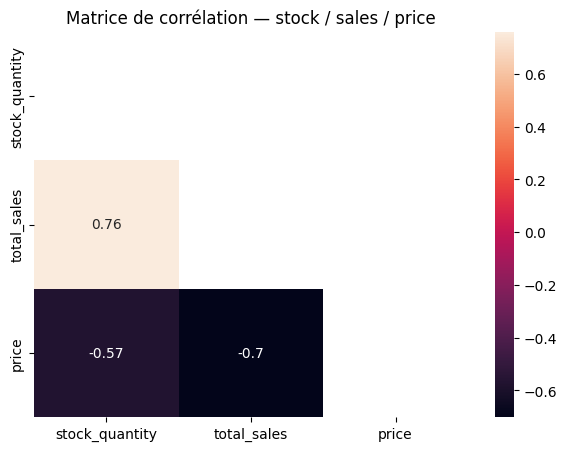

In [62]:
############################
# Analyse des corrélations #
############################

#Importation de Seaborn
import seaborn as sns # C'est une librairie python basée sur matplotlib pour rendre les graphiques plus esthétiques et aussi ajouter des possibilités de graph mais reste statique alors que plotly express est interactif

#Création d'une heatmap de corrélation avec les variables stock, sales et price
#On peut également créer un mask pour n'afficher qu'une demi heatmap

# Choisir les colonnes
candidates = ['stock_quantity', 'total_sales', 'price']

# Création du coefficient de corrélation
correlation = df_merge_global[candidates].corr(method='spearman') # .corr() calcul la matrice de corrélation on utilise spearman ici et non pearson car on a beaucoup d'outliers et pearson y est sensible

# Mask pour ne garder que la moitié supérieure
mask2 = np.triu(np.ones_like(correlation, dtype=bool)) # np.ones_like va créer un array booléen a partir de correlation puis np.triu va sélectionner comme true la partie supérieur du triangle donc les données de la moitié supérieure
print(mask2)

# Création de la mheat map
plt.figure(figsize=(7, 5))
sns.heatmap(
    correlation,
    mask = mask2,
    annot=True,   #annot permet d'afficher les scores exacts sur le graph
)
plt.title("Matrice de corrélation — stock / sales / price")
plt.show()

#pourrait etre intéressant d'analyser la distribution pour savoir si utiliser pearson ou spearman

In [63]:
#Que peut-on conclure des corrélations ? Attention corrélation différent de causalité !

# Stock / Ventes
# corrélation positive forte : en général, plus il y a de stock, plus les ventes sont élevées. C’est logique : les produits avec plus d’offre ont aussi plus de ventes

# Ventes / Prix
# corrélation négative forte : les bouteilles les plus chères se vendent moins (ou inversement, les plus vendues sont souvent moins chères). Ça ressemble à de la sensibilité au prix

# Stock / Prix
# corrélation négative forte : Moins de stock pour les bouteilles les plus chères. Logique car moins de vente également.

In [64]:
print("Le kurtosis des prix est de :", round(df_merge_global['price'].kurtosis(),2)) #cette valeur montre que la distribution est plus pointue au centre et qu'il y a beaucoups d'outliers

print("Le kurtosis des ventes est de :", round(df_merge_global['total_sales'].kurtosis(),2)) #cette valeur montre que la distribution est proche d'une distribution normale

print("Le kurtosis du stock est de :", round(df_merge_global['stock_quantity'].kurtosis(),2)) #cette valeur montre que la distribution est plus pointue au centre et qu'il y a beaucoups d'outliers

Le kurtosis des prix est de : 10.32
Le kurtosis des ventes est de : 3.02
Le kurtosis du stock est de : 9.91


## Etape 5.6 - Mise à disposition de la nouvelle table sur un fichier Excel

In [65]:
#Mettre le dataset df_merge sur un fichier Excel
df_merge_global.to_excel('df_merge_global.xlsx', index=False)
#Cette étape peut être utile pour partager le résultat du dataset obtenu avec les équipes.
